
=== Training on Debian → Testing on Chrome (ADASYN) ===
Debian dataset shape: (18298, 1024)
Chrome dataset shape: (4436, 1024)

Applying ADASYN to balance Debian dataset...
After ADASYN: (33511, 1024)

=== Ensemble Iteration 1/3 ===

Training Neural Network on Debian (ADASYN balanced)...
Epoch 1/50
Processing batch 0
 50/419 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5382 - loss: 0.6930Processing batch 50
 98/419 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5516 - loss: 0.6888Processing batch 100
150/419 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5615 - loss: 0.6847Processing batch 150
199/419 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5682 - loss: 0.6812Processing batch 200
248/419 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5741 - loss: 0.6775Processing batch 250
298/419 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5793 - loss: 0.6739Processing batch 300
348/419 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5839 - loss: 0.6705Processing batch 350
399/419 ━

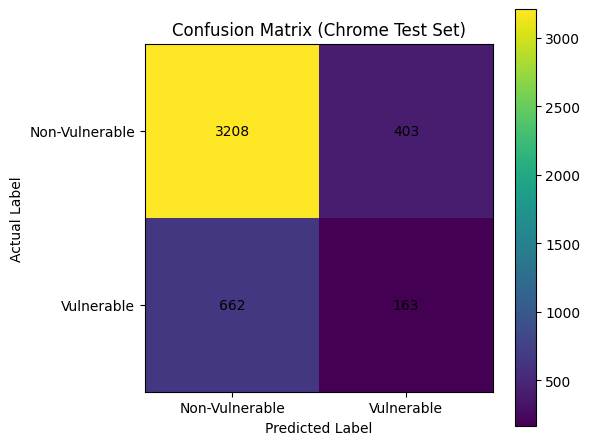

In [1]:
"""
Cross-Project Vulnerability Detection (ADASYN Version)
------------------------------------------------------
Train on Debian → Test on Chrome
Handles class imbalance using ADASYN
"""

# =========================================================
# Imports
# =========================================================

import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    f1_score,
    confusion_matrix
)

from xgboost import XGBClassifier

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import Callback

from imblearn.over_sampling import ADASYN

warnings.filterwarnings("ignore")

# =========================================================
# TensorFlow Configuration
# =========================================================

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

tf.config.run_functions_eagerly(True)

tf.config.threading.set_inter_op_parallelism_threads(0)
tf.config.threading.set_intra_op_parallelism_threads(0)

os.environ["OMP_NUM_THREADS"] = "8"

# =========================================================
# Progress Logger
# =========================================================

class BatchLogger(Callback):

    def on_train_batch_begin(self, batch, logs=None):
        if batch % 50 == 0:
            print(f"Processing batch {batch}")

# =========================================================
# Reproducibility
# =========================================================

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

os.environ["PYTHONHASHSEED"] = str(seed)

# =========================================================
# Original Configuration
# =========================================================

EPOCHS_INITIAL = 50
EPOCHS_RETRAIN = 30

BATCH_SIZE_INITIAL = 64
BATCH_SIZE_RETRAIN = 32

LEARNING_RATE = 1e-5
NUM_ITERATIONS = 3

# =========================================================
# Neural Network
# =========================================================

def create_neural_network(input_dim: int):

    model = Sequential([
        Dense(256, activation="relu", input_dim=input_dim),
        Dropout(0.2),

        Dense(128, activation="relu"),
        Dropout(0.2),

        Dense(64, activation="relu"),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dropout(0.2),

        Dense(16, activation="relu"),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =========================================================
# Semi-supervised Transfer Learning
# =========================================================

def semi_supervised_transfer_learning(
        x_train,
        y_train,
        x_test):

    model = create_neural_network(x_train.shape[1])

    print("\nTraining Neural Network on Debian (ADASYN balanced)...")

    model.fit(
        x_train,
        y_train,
        epochs=EPOCHS_INITIAL,
        batch_size=BATCH_SIZE_INITIAL,
        validation_split=0.2,
        callbacks=[BatchLogger()],
        verbose=1
    )

    print("\nGenerating pseudo labels for Chrome dataset...")

    y_pred = model.predict(x_test, verbose=0)

    y_pred_binary = (y_pred > 0.5).astype(int).flatten()

    x_train_aug = np.concatenate((x_train, x_test))
    y_train_aug = np.concatenate((y_train, y_pred_binary))

    print("\nRetraining model with pseudo-labelled Chrome data...")

    model.fit(
        x_train_aug,
        y_train_aug,
        epochs=EPOCHS_RETRAIN,
        batch_size=BATCH_SIZE_RETRAIN,
        verbose=1
    )

    return model, y_pred.flatten()


# =========================================================
# XGBoost
# =========================================================

def train_base_model_xgb(x_train, y_train):

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        use_label_encoder=False,
        eval_metric="logloss"
    )

    model.fit(x_train, y_train)

    return model


# =========================================================
# Main
# =========================================================

def main():

    print("\n=== Training on Debian → Testing on Chrome (ADASYN) ===")

    # -----------------------------------------------------
    # Load Embeddings
    # -----------------------------------------------------

    deb_emb = np.load("dataset/debian_embeddings.npy")
    deb_lbl = np.load("dataset/debian_labels.npy")

    chr_emb = np.load("dataset/chrome_embeddings.npy")
    chr_lbl = np.load("dataset/chrome_labels.npy")

    deb_emb = deb_emb.astype(np.float32)
    chr_emb = chr_emb.astype(np.float32)

    deb_lbl = deb_lbl.astype(np.float32)
    chr_lbl = chr_lbl.astype(np.float32)

    print("Debian dataset shape:", deb_emb.shape)
    print("Chrome dataset shape:", chr_emb.shape)

    # -----------------------------------------------------
    # Normalize
    # -----------------------------------------------------

    scaler = StandardScaler()

    deb_emb = scaler.fit_transform(deb_emb)
    chr_emb = scaler.transform(chr_emb)

    # -----------------------------------------------------
    # Apply ADASYN
    # -----------------------------------------------------

    print("\nApplying ADASYN to balance Debian dataset...")

    adasyn = ADASYN(random_state=seed)

    deb_emb_balanced, deb_lbl_balanced = adasyn.fit_resample(
        deb_emb,
        deb_lbl
    )

    print("After ADASYN:", deb_emb_balanced.shape)

    # -----------------------------------------------------
    # Ensemble Training
    # -----------------------------------------------------

    ensemble_predictions = np.zeros(len(chr_lbl))

    for i in range(NUM_ITERATIONS):

        print(f"\n=== Ensemble Iteration {i+1}/{NUM_ITERATIONS} ===")

        model_nn, _ = semi_supervised_transfer_learning(
            deb_emb_balanced,
            deb_lbl_balanced,
            chr_emb
        )

        print("\nTraining XGBoost model...")

        model_xgb = train_base_model_xgb(
            deb_emb_balanced,
            deb_lbl_balanced
        )

        print("Predicting Chrome dataset...")

        model_xgb_pred = model_xgb.predict(chr_emb)

        ensemble_predictions += model_xgb_pred

    # -----------------------------------------------------
    # Average Predictions
    # -----------------------------------------------------

    ensemble_avg = ensemble_predictions / NUM_ITERATIONS

    y_pred_final = (ensemble_avg > 0.5).astype(int)

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    accuracy = accuracy_score(chr_lbl, y_pred_final)
    recall = recall_score(chr_lbl, y_pred_final)
    precision = precision_score(chr_lbl, y_pred_final)
    auc = roc_auc_score(chr_lbl, ensemble_avg)
    f1 = f1_score(chr_lbl, y_pred_final)

    tn, fp, fn, tp = confusion_matrix(chr_lbl, y_pred_final).ravel()

    g_mean = np.sqrt(tp / (tp + fn))
    pf = fp / (fp + tn)

    print("\n=== Evaluation Results (Chrome Test Set) ===")

    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"AUC:       {auc:.3f}")
    print(f"G-mean:    {g_mean:.3f}")
    print(f"PF value:  {pf:.3f}")

    print("\nConfusion Matrix:")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")

    # -----------------------------------------------------
    # Plot Confusion Matrix
    # -----------------------------------------------------

    cm = confusion_matrix(chr_lbl, y_pred_final)

    plt.figure(figsize=(6, 5))

    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (Chrome Test Set)")
    plt.colorbar()

    tick_marks = np.arange(2)

    plt.xticks(tick_marks, ["Non-Vulnerable", "Vulnerable"])
    plt.yticks(tick_marks, ["Non-Vulnerable", "Vulnerable"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()


# =========================================================

if __name__ == "__main__":
    main()